# Linear Regression

## Preprocessing

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset.csv', na_values='?')
price_cols = ['open','high','low','close','next_weeks_open','next_weeks_close']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

df = df.drop(['stock','quarter','date','next_weeks_open','percent_change_next_weeks_price'], axis=1).dropna()

X = df.drop(columns='next_weeks_close')
y = df['next_weeks_close']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Shapes: (432, 10) (144, 10) (144, 10)


## Modeling Across Transformations

apply feature sets:

1. Original standardized features
2. Polynomial features (degree=2)
3. PCA (95% variance)
4. SelectKBest (top 5 features)

In [2]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

transformers = {
    'original': None,
    'polynomial': PolynomialFeatures(degree=2, include_bias=False),
    'pca': PCA(n_components=0.95, random_state=42),
    'kbest': SelectKBest(score_func=f_regression, k=5)
}

alphas = [0.01, 0.1, 1, 10, 100, 1000]
results = []

for name, transformer in transformers.items():
    if name == 'original':
        Xtr, Xvl, Xts = X_train_scaled, X_val_scaled, X_test_scaled
    else:
        if name == 'polynomial':
            Xt_train = transformer.fit_transform(X_train_scaled)
            Xt_val   = transformer.transform(X_val_scaled)
            Xt_test  = transformer.transform(X_test_scaled)
        else:
            Xt_train = transformer.fit_transform(X_train_scaled, y_train) if name=='kbest' else transformer.fit_transform(X_train_scaled)
            Xt_val   = transformer.transform(X_val_scaled)
            Xt_test  = transformer.transform(X_test_scaled)
        Xtr, Xvl, Xts = Xt_train, Xt_val, Xt_test

    lr = LinearRegression().fit(Xtr, y_train)
    for ds, Xs, ys in [('Train', Xtr, y_train), ('Val', Xvl, y_val)]:
        pred = lr.predict(Xs)
        results.append({
            'Model': 'Linear',
            'Transformation': name,
            'Alpha': None,
            'Dataset': ds,
            'MSE': mean_squared_error(ys, pred),
            'R2': r2_score(ys, pred)
        })

    for alpha in alphas:
        rd = Ridge(alpha=alpha, random_state=42).fit(Xtr, y_train)
        for ds, Xs, ys in [('Train', Xtr, y_train), ('Val', Xvl, y_val)]:
            pred = rd.predict(Xs)
            results.append({
                'Model': 'Ridge',
                'Transformation': name,
                'Alpha': alpha,
                'Dataset': ds,
                'MSE': mean_squared_error(ys, pred),
                'R2': r2_score(ys, pred)
            })

results_df = pd.DataFrame(results)
results_df

,Model,Transformation,Alpha,Dataset,MSE,R2
0,Linear,original,NaN,Train,2.305467,0.997928
1,Linear,original,NaN,Val,2.914730,0.997611
2,Ridge,original,0.01,Train,2.307433,0.997926
3,Ridge,original,0.01,Val,2.910114,0.997615
4,Ridge,original,0.10,Train,2.372407,0.997868
5,Ridge,original,0.10,Val,2.951095,0.997581
6,Ridge,original,1.00,Train,2.561898,0.997697
7,Ridge,original,1.00,Val,3.132547,0.997433
8,Ridge,original,10.00,Train,2.679697,0.997592
9,Ridge,original,10.00,Val,3.187666,0.997387


## Results Visualization

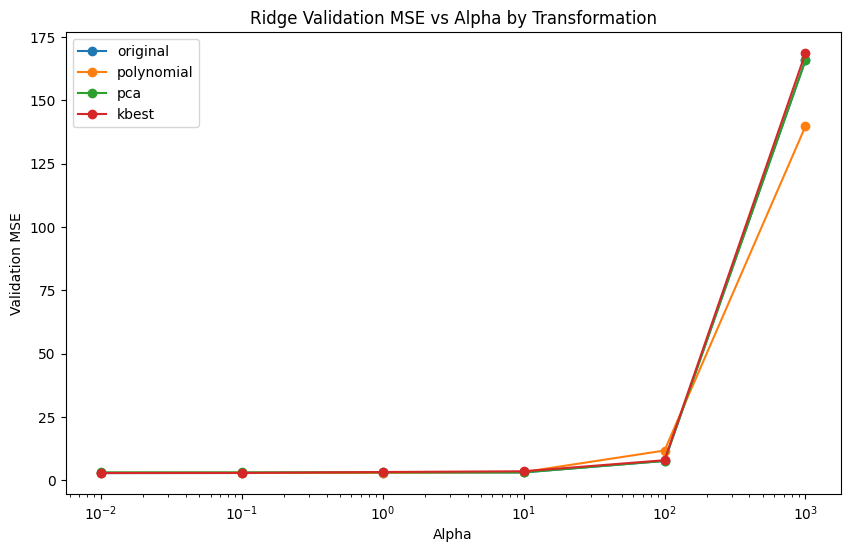

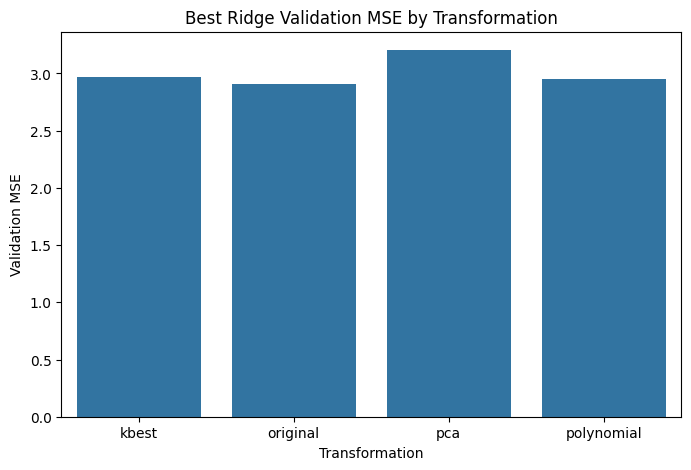

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

ridge_val = results_df[(results_df.Model=='Ridge') & (results_df.Dataset=='Val')]

plt.figure(figsize=(10, 6))
for name in transformers.keys():
    subset = ridge_val[ridge_val.Transformation==name]
    plt.plot(subset.Alpha, subset.MSE, marker='o', label=name)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Validation MSE')
plt.title('Ridge Validation MSE vs Alpha by Transformation')
plt.legend()
plt.show()

best_ridge = ridge_val.loc[ridge_val.groupby('Transformation').MSE.idxmin()]
plt.figure(figsize=(8, 5))
sns.barplot(data=best_ridge, x='Transformation', y='MSE')
plt.title('Best Ridge Validation MSE by Transformation')
plt.ylabel('Validation MSE')
plt.show()

## Final Model Selection and Test Evaluation

In [4]:
best_idx = ridge_val.MSE.idxmin()
best_cfg = ridge_val.loc[best_idx]
print("Best configuration:", best_cfg)

from numpy import vstack
X_full = vstack([X_train_scaled, X_val_scaled])
Y_full = pd.concat([y_train, y_val])

best_name = best_cfg.Transformation
best_alpha = best_cfg.Alpha
if best_name=='original':
    XF, XT = X_full, X_test_scaled
elif best_name=='polynomial':
    poly = PolynomialFeatures(degree=2, include_bias=False)
    XF = poly.fit_transform(X_full)
    XT = poly.transform(X_test_scaled)
elif best_name=='pca':
    pca = PCA(n_components=0.95, random_state=42)
    XF = pca.fit_transform(X_full)
    XT = pca.transform(X_test_scaled)
else:
    kbest = SelectKBest(score_func=f_regression, k=5)
    XF = kbest.fit_transform(X_full, Y_full)
    XT = kbest.transform(X_test_scaled)

final_model = Ridge(alpha=best_alpha, random_state=42).fit(XF, Y_full)
pred_test = final_model.predict(XT)
from sklearn.metrics import mean_squared_error, r2_score
print("Test MSE:", mean_squared_error(y_test, pred_test))
print("Test R2:", r2_score(y_test, pred_test))

Best configuration: Model                Ridge
Transformation    original
Alpha                 0.01
Dataset                Val
MSE               2.910114
R2                0.997615
Name: 3, dtype: object
Test MSE: 2.5116482780767146
Test R2: 0.9972456434614503
